<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/unet_segmentation_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Topic:** Semantic Image Segmentation using U-Net

**Objective:** Perform pixel-wise classification using U-Net architecture.

**Dataset:** Oxford-IIIT Pet Dataset

**Course Outcome:** CO5

---

This notebook will guide you step-by-step:
- Load and preprocess dataset
- Build U-Net model
- Train model
- Visualize predictions


In [ ]:
!pip install -q tensorflow tensorflow-datasets matplotlib

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.19.0


## Load Dataset

In [ ]:
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True)

train_data = dataset['train']
test_data = dataset['test']

print(info)

## Preprocessing

In [ ]:
IMG_SIZE = 128

def preprocess(data):
    image = tf.image.resize(data['image'], (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(data['segmentation_mask'], (IMG_SIZE, IMG_SIZE))

    image = tf.cast(image, tf.float32) / 255.0
    mask -= 1

    return image, mask

train = train_data.map(preprocess).batch(16).prefetch(tf.data.AUTOTUNE)
test = test_data.map(preprocess).batch(16)

## Visualize Sample

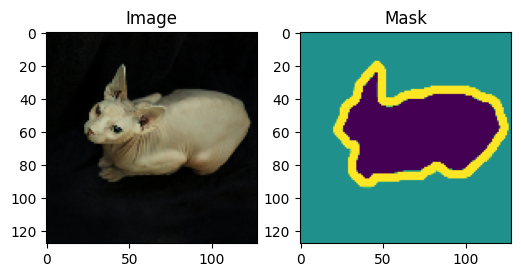

In [ ]:
def display(image, mask):
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.title("Image")
    plt.imshow(image)

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(mask[:,:,0])
    plt.show()

for img, mask in train.take(1):
    display(img[0], mask[0])


## Build U-Net Model

In [ ]:
def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def encoder_block(x, filters):
    f = conv_block(x, filters)
    p = tf.keras.layers.MaxPooling2D()(f)
    return f, p

def decoder_block(x, skip, filters):
    x = tf.keras.layers.Conv2DTranspose(filters, 2, strides=2, padding='same')(x)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet():
    inputs = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))

    f1, p1 = encoder_block(inputs, 64)
    f2, p2 = encoder_block(p1, 128)
    f3, p3 = encoder_block(p2, 256)

    bottleneck = conv_block(p3, 512)

    d1 = decoder_block(bottleneck, f3, 256)
    d2 = decoder_block(d1, f2, 128)
    d3 = decoder_block(d2, f1, 64)

    outputs = tf.keras.layers.Conv2D(3, 1, activation='softmax')(d3)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_unet()
model.summary()

## Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [ ]:
history = model.fit(
    train,
    validation_data=test,
    epochs=5
)

Epoch 1/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 91s 266ms/step - accuracy: 0.6492 - loss: 0.7713 - val_accuracy: 0.7059 - val_loss: 0.6977
Epoch 2/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 52s 225ms/step - accuracy: 0.7291 - loss: 0.6409 - val_accuracy: 0.7202 - val_loss: 0.6841
Epoch 3/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 54s 233ms/step - accuracy: 0.7671 - loss: 0.5656 - val_accuracy: 0.7484 - val_loss: 0.6176
Epoch 4/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 54s 236ms/step - accuracy: 0.7972 - loss: 0.4949 - val_accuracy: 0.8014 - val_loss: 0.4896
Epoch 5/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 56s 243ms/step - accuracy: 0.8140 - loss: 0.4564 - val_accuracy: 0.8170 - val_loss: 0.4429


## Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step


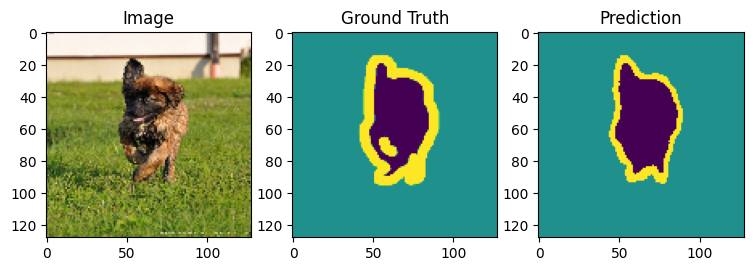

In [ ]:
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask

for image, mask in test.take(1):
    pred = model.predict(image)
    pred_mask = create_mask(pred)

    plt.figure(figsize=(9,3))

    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image[0])

    plt.subplot(1,3,2)
    plt.title("Ground Truth")
    plt.imshow(mask[0][:,:,0])

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow(pred_mask[0][:,:,0])

    plt.show()